# 03 - Model, backtest and risk
Gradient Boosting on past sales (6/8/12/52 weeks ago), promo days, holidays and time of year. Every lag is at least 6 weeks old = **no data leakage**. Tested by **rolling-origin backtest**: 4 windows x 6 weeks.

In [1]:
import sys; sys.path.append('..')
import sqlite3, pandas as pd, matplotlib.pyplot as plt
con = sqlite3.connect('../data/stocksense.db')
rd = lambda t: pd.read_sql(f'select * from {t}', con)

In [2]:
rd('model_scores').round(3)

,baseline_wape,model_wape,baseline_bias,model_bias,backtest_rows,winner
0,0.166,0.145,-0.067,0.01,288,model


Model WAPE lower than baseline WAPE means the model wins. The code picks the winner automatically.

## Forecast for the next 6 weeks with 80% range

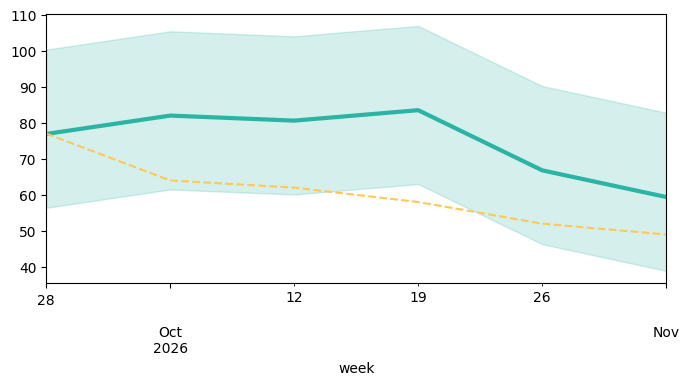

In [3]:
f = rd('forecast'); f['week'] = pd.to_datetime(f.week); x = f[f.sku_id=='K01'].set_index('week')
ax = x.forecast.plot(figsize=(8,3.5), color='#2BB3A3', lw=3); ax.fill_between(x.index, x.low, x.high, alpha=.2, color='#2BB3A3'); x.baseline.plot(ax=ax, ls='--', color='#FFC857'); plt.show()

## Risk decision for every product
Stockout risk uses the high forecast, overstock risk the low forecast. >= 0.5 is 'high'.

In [4]:
rd('risk')[['product_name','weeks_of_cover','stockout_risk','overstock_risk','action','suggested_order_qty','sales_at_risk','capital_locked']]

,product_name,weeks_of_cover,stockout_risk,overstock_risk,action,suggested_order_qty,sales_at_risk,capital_locked
0,Bedsheet Set,4.2,0.43,0.21,Healthy,0,0,0
1,Pillow,8.3,0.00,0.44,Healthy,0,0,3020
2,Table Lamp,3.7,0.49,0.16,Healthy,0,0,0
3,Wall Clock,6.2,0.00,0.33,Healthy,0,0,0
4,Coffee Mug,4.1,0.14,0.21,Healthy,0,0,0
5,Lunch Box,6.6,0.00,0.35,Healthy,0,0,0
6,Table Fan,32.8,0.00,1.00,Markdown / clear,0,0,643140
7,Photo Frame,29.5,0.00,1.00,Markdown / clear,0,0,38382
8,Blanket,2.8,0.71,0.12,Reorder now,206,97835,0
9,Electric Kettle,2.2,0.69,0.09,Reorder now,175,63836,0
